# XGBoost Training With RMSLE Logging

Notebook tối giản để train XGBoost bằng bộ tham số tối ưu từ `notebooks/07_evaluation/XGBoost_training_out.ipynb`, log eval set và plot RMSLE theo từng boosting round.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_log_error
from sklearn.preprocessing import LabelEncoder


In [2]:
def find_project_root(start: Path | None = None) -> Path:
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    candidates = [start, *start.parents]

    for candidate in candidates:
        if (candidate / "data" / "processed" / "splits").exists():
            return candidate
        nested = candidate / "Topic_13_Retail_Store_Sales_Time_Series"
        if (nested / "data" / "processed" / "splits").exists():
            return nested

    raise FileNotFoundError("Could not locate project root containing data/processed/splits")


BASE = find_project_root()
SPLIT_DIR = BASE / "data" / "processed" / "splits"

X_train = pd.read_csv(SPLIT_DIR / "train_features.csv")
y_train = pd.read_csv(SPLIT_DIR / "train_target.csv")
X_val = pd.read_csv(SPLIT_DIR / "val_features.csv")
y_val = pd.read_csv(SPLIT_DIR / "val_target.csv")
y_val_orig = pd.read_csv(SPLIT_DIR / "val_target_original.csv")

print(f"BASE: {BASE}")
print(f"X_train {X_train.shape} | X_val {X_val.shape}")


BASE: D:\Topic_13_Project\Topic_13_Retail_Store_Sales_Time_Series
X_train (2918916, 49) | X_val (55242, 49)


In [3]:
object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
label_encoders = {}

for col in object_cols:
    encoder = LabelEncoder()
    combined = pd.concat([X_train[col], X_val[col]], ignore_index=True).astype(str)
    encoder.fit(combined)

    X_train[col] = encoder.transform(X_train[col].astype(str)).astype(np.int32)
    X_val[col] = encoder.transform(X_val[col].astype(str)).astype(np.int32)
    label_encoders[col] = encoder

remaining_object_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
if remaining_object_cols:
    raise ValueError(f"Still has object columns: {remaining_object_cols}")

print(f"Label encoded {len(object_cols)} columns")


Label encoded 6 columns


In [4]:
def rmsle_from_log_arrays(y_true_log, y_pred_log) -> float:
    y_true = np.clip(np.expm1(np.asarray(y_true_log)), 0, None)
    y_pred = np.clip(np.expm1(np.asarray(y_pred_log)), 0, None)
    return float(np.sqrt(mean_squared_log_error(y_true, y_pred)))


def final_val_summary(model_name: str, val_pred_log) -> pd.DataFrame:
    summary = pd.DataFrame(
        {
            "model": [model_name],
            "val_rmsle": [rmsle_from_log_arrays(y_val["sales_log"], val_pred_log)],
            "best_round": [int(history.loc[history["val_rmsle"].idxmin(), "round"])],
            "best_val_rmsle": [float(history["val_rmsle"].min())],
        }
    )
    return summary


def plot_history(model_name: str) -> None:
    plt.figure(figsize=(12, 5))
    plt.plot(history["round"], history["train_rmsle"], label="Train RMSLE", linewidth=2)
    plt.plot(history["round"], history["val_rmsle"], label="Validation RMSLE", linewidth=2)
    best_idx = history["val_rmsle"].idxmin()
    plt.scatter(
        history.loc[best_idx, "round"],
        history.loc[best_idx, "val_rmsle"],
        color="crimson",
        s=60,
        label=f"Best val round = {int(history.loc[best_idx, 'round'])}",
        zorder=3,
    )
    plt.title(f"{model_name} RMSLE by Boosting Round")
    plt.xlabel("Boosting round")
    plt.ylabel("RMSLE")
    plt.grid(alpha=0.25)
    plt.legend()
    plt.tight_layout()
    plt.show()


In [5]:
import xgboost as xgb


def rmsle_xgb(y_true_log, y_pred_log):
    return rmsle_from_log_arrays(y_true_log, y_pred_log)


best_params = {
    "n_estimators": 1000,
    "learning_rate": 0.05661765609380996,
    "max_depth": 10,
    "min_child_weight": 62,
    "subsample": 0.891754215404674,
    "colsample_bytree": 0.7928782229160452,
    "reg_alpha": 0.06528187294151135,
    "reg_lambda": 0.05430278926785755,
    "objective": "reg:squarederror",
    "tree_method": "hist",
    "random_state": 42,
    "n_jobs": -1,
    "eval_metric": rmsle_xgb,
}

model = xgb.XGBRegressor(**best_params)
model.fit(
    X_train,
    y_train["sales_log"],
    eval_set=[(X_train, y_train["sales_log"]), (X_val, y_val["sales_log"])],
    verbose=100,
)


[0]	validation_0-rmse:2.54868	validation_0-rmsle_xgb:2.54868	validation_1-rmse:2.49627	validation_1-rmsle_xgb:2.49627
[100]	validation_0-rmse:0.37014	validation_0-rmsle_xgb:0.37000	validation_1-rmse:0.37463	validation_1-rmsle_xgb:0.37463
[200]	validation_0-rmse:0.35564	validation_0-rmsle_xgb:0.35537	validation_1-rmse:0.37198	validation_1-rmsle_xgb:0.37198
[300]	validation_0-rmse:0.34757	validation_0-rmsle_xgb:0.34726	validation_1-rmse:0.37112	validation_1-rmsle_xgb:0.37111
[400]	validation_0-rmse:0.34133	validation_0-rmsle_xgb:0.34100	validation_1-rmse:0.37029	validation_1-rmsle_xgb:0.37028
[500]	validation_0-rmse:0.33683	validation_0-rmsle_xgb:0.33648	validation_1-rmse:0.36975	validation_1-rmsle_xgb:0.36974
[600]	validation_0-rmse:0.33277	validation_0-rmsle_xgb:0.33241	validation_1-rmse:0.36953	validation_1-rmsle_xgb:0.36950
[700]	validation_0-rmse:0.32917	validation_0-rmsle_xgb:0.32880	validation_1-rmse:0.36926	validation_1-rmsle_xgb:0.36924
[800]	validation_0-rmse:0.32596	validation

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7928782229160452, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=<function rmsle_xgb at 0x000002C4301BF240>,
             feature_types=None, feature_weights=None, gamma=None,
             grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05661765609380996,
             max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=10, max_leaves=None,
             min_child_weight=62, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=1000, n_jobs=-1,
             num_parallel_tree=None, ...)

In [6]:
results = model.evals_result()
metric_name = next(
    key for key in results["validation_0"].keys() if "rmsle" in key.lower()
)

history = pd.DataFrame(
    {
        "round": np.arange(1, len(results["validation_0"][metric_name]) + 1),
        "train_rmsle": results["validation_0"][metric_name],
        "val_rmsle": results["validation_1"][metric_name],
    }
)

history.head()


,round,train_rmsle,val_rmsle
0,1,2.548685,2.496274
1,2,2.408869,2.358643
2,3,2.277355,2.229338
3,4,2.153639,2.107668
4,5,2.037353,1.993102


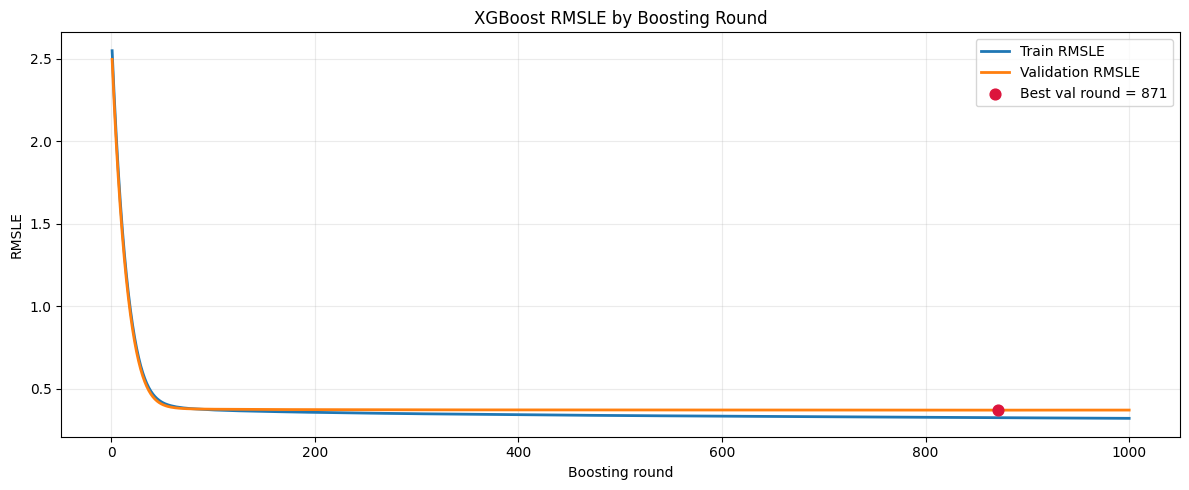

,model,val_rmsle,best_round,best_val_rmsle
0,XGBoost,0.36936,871,0.368952


In [7]:
plot_history("XGBoost")

val_pred_log = model.predict(X_val)
summary = final_val_summary("XGBoost", val_pred_log)
summary
